<a href="https://colab.research.google.com/github/Prajjwal2123/internship-assignments/blob/main/week5_Prajjwal_sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
machine learning enables intelligent systems
artificial intelligence is changing the world
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
machine learning enables intelligent systems
artificial intelligence is changing the world



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("\nVocabulary Size:", total_words)


Vocabulary Size: 43


CREATING N-GRAM SEQUENCES

In [4]:
input_sequences = []

for line in corpus.strip().split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (44, 7)
y Shape: (44,)


TRAIN TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))



Training Samples: 35
Testing Samples : 9


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
def build_model(model_type):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=total_words,
            output_dim=64,
            input_length=max_len - 1
        )
    )

    if model_type == "RNN":
        model.add(SimpleRNN(128))

    elif model_type == "LSTM":
        model.add(LSTM(128))

    elif model_type == "GRU":
        model.add(GRU(128))

    model.add(Dense(total_words, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
print("\nTraining Vanilla RNN...")

rnn_model = build_model("RNN")

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    verbose=0
)

print("RNN Training Completed")


Training Vanilla RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


RNN Training Completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [8]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


In [9]:
print("\nTraining LSTM...")

lstm_model = build_model("LSTM")

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    verbose=0
)

print("LSTM Training Completed")



Training LSTM...
LSTM Training Completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [10]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


In [11]:
print("\nTraining GRU...")

gru_model = build_model("GRU")

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    verbose=0
)

print("GRU Training Completed")


Training GRU...
GRU Training Completed


## 📉 Compare Training Loss

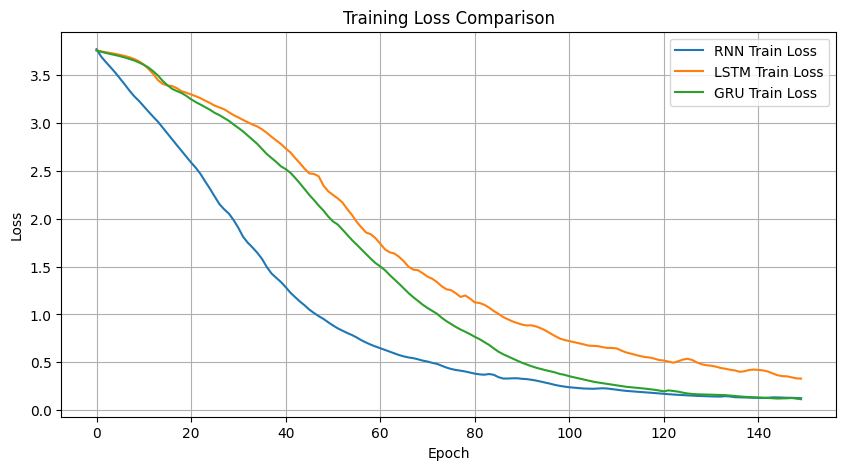

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN Train Loss'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM Train Loss'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU Train Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


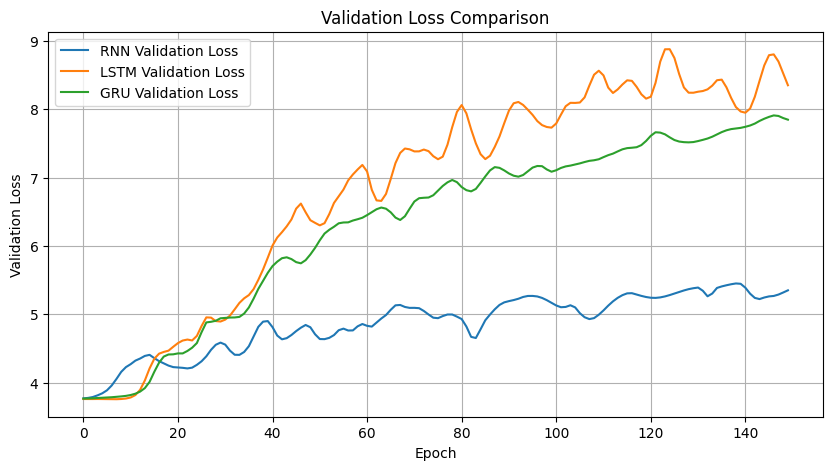

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['val_loss'],
    label='RNN Validation Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='LSTM Validation Loss'
)

plt.plot(
    gru_history.history['val_loss'],
    label='GRU Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

EVALUATION

In [14]:
def evaluate_model(model, name):

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    perplexity = np.exp(loss)

    return [name, loss, accuracy, perplexity]

results = []

results.append(
    evaluate_model(rnn_model, "Vanilla RNN")
)

results.append(
    evaluate_model(lstm_model, "LSTM")
)

results.append(
    evaluate_model(gru_model, "GRU")
)

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Loss",
        "Accuracy",
        "Perplexity"
    ]
)

print("\nMODEL COMPARISON")
print(results_df)


MODEL COMPARISON
         Model      Loss  Accuracy   Perplexity
0  Vanilla RNN  5.351741       0.0   210.975252
1         LSTM  8.352787       0.0  4241.986776
2          GRU  7.848944       0.0  2563.025589


PARAMETER COMPARISON

In [15]:
print("\nRNN Summary")
rnn_model.summary()

print("\nLSTM Summary")
lstm_model.summary()

print("\nGRU Summary")
gru_model.summary()


RNN Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 7, 64)          │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,011 (386.77 KB)

 Trainable params: 33,003 (128.92 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 7, 64)          │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,387 (970.27 KB)

 Trainable params: 82,795 (323.42 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 165,592 (646.85 KB)

TEMPERATURE SAMPLING

In [16]:
def sample_with_temperature(predictions,
                            temperature=1.0):

    predictions = np.asarray(predictions).astype("float64")

    predictions = np.log(predictions + 1e-8)

    predictions = predictions / temperature

    exp_preds = np.exp(predictions)

    predictions = exp_preds / np.sum(exp_preds)

    return np.random.choice(
        len(predictions),
        p=predictions
    )


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [17]:
def generate_text(model,
                  seed_text,
                  next_words=10,
                  temperature=0.8):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding='pre'
        )

        predictions = model.predict(
            token_list,
            verbose=0
        )[0]

        predicted_index = sample_with_temperature(
            predictions,
            temperature
        )

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text


## 🧪 Generate Text Samples

In [18]:
print("\nTEXT GENERATION RESULTS\n")

print("RNN:")
print(generate_text(
    rnn_model,
    "deep learning",
    next_words=10
))

print("\nLSTM:")
print(generate_text(
    lstm_model,
    "deep learning",
    next_words=10
))

print("\nGRU:")
print(generate_text(
    gru_model,
    "deep learning",
    next_words=10
))


TEXT GENERATION RESULTS

RNN:
deep learning models can generate meaningful artificial the sequential than lstm next

LSTM:
deep learning models artificial artificial meaningful meaningful long long systems world machine

GRU:
deep learning is transforming artificial simpler than lstm word lstm word world


BEST MODEL

In [19]:
best_model = results_df.sort_values(
    by="Perplexity"
).iloc[0]

print("\nBest Model Based on Perplexity:")
print(best_model)


Best Model Based on Perplexity:
Model         Vanilla RNN
Loss             5.351741
Accuracy              0.0
Perplexity     210.975252
Name: 0, dtype: object


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**